C:\Users\FRANCIS STARWIN M\AppData\Local\Temp\ipykernel_16628\1697912767.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


Shape: (1008, 8)

Missing values:
 Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
Zone                                       0
dtype: int64

Shape after cleaning: (1008, 11)

Region-wise average unemployment rate (top 10):
 Region
Tripura             19.87
Haryana             19.16
Jammu & Kashmir     16.89
Chandigarh          16.08
Delhi               15.00
Jharkhand           14.52
Punjab              14.03
Goa                 13.73
Kerala              13.47
Himachal Pradesh    13.15
Name: Estimated Unemployment Rate (%), dtype: float64

Month-wise all-India average:
 Date
2019-05-31     7.81
2019-06-30     7.78
2019-07-31     7.74
2019-08-31     7.76
2019-09-30     7.80
2019-10-31     7.77
2019-11-30     7.75
2019-12-31

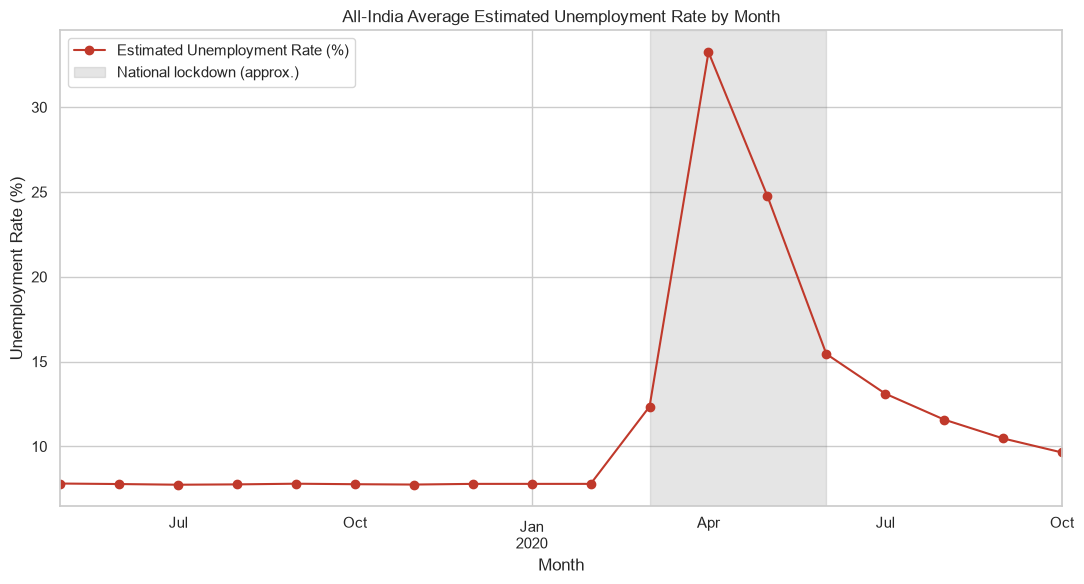

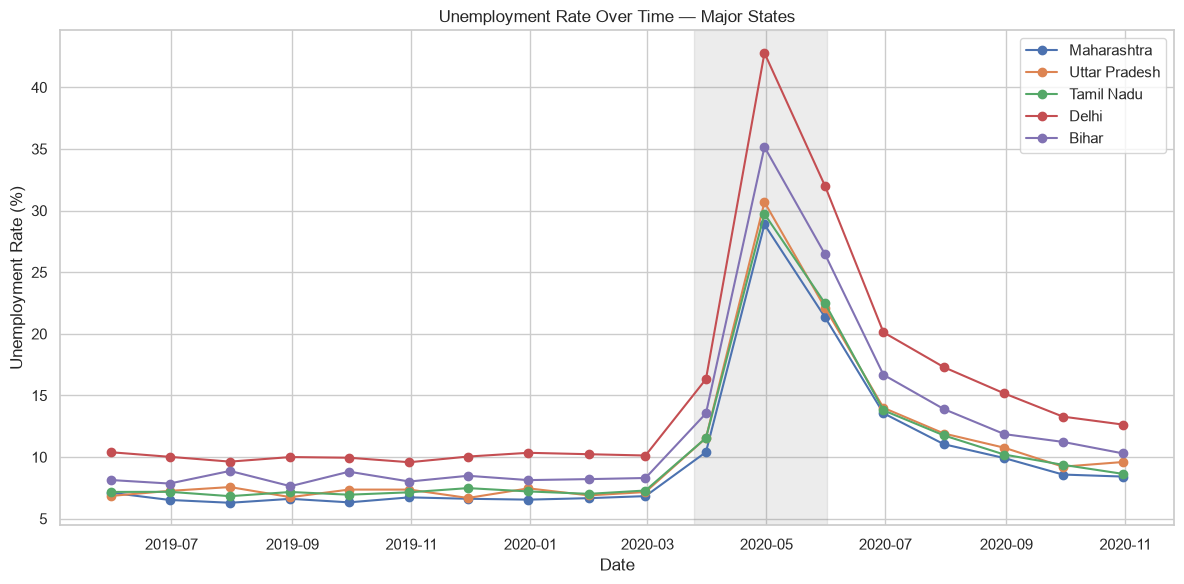

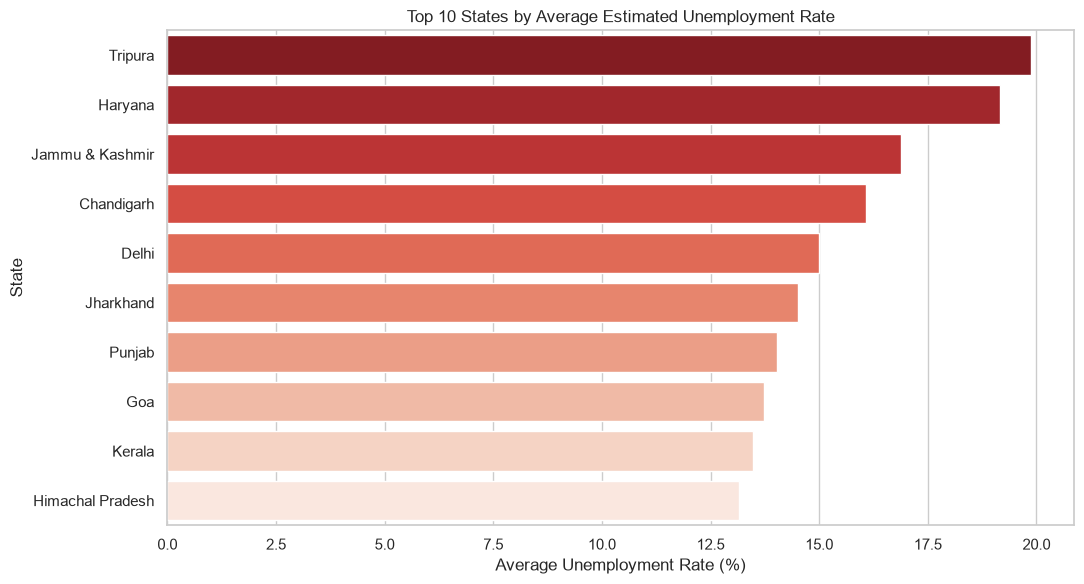

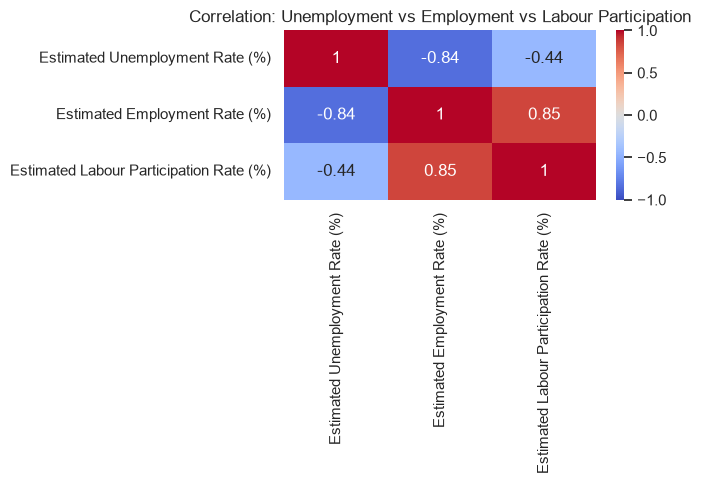


Correlation matrix:
                                          Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                     1.00   
Estimated Employment Rate (%)                                      -0.84   
Estimated Labour Participation Rate (%)                            -0.44   

                                         Estimated Employment Rate (%)  \
Estimated Unemployment Rate (%)                                  -0.84   
Estimated Employment Rate (%)                                     1.00   
Estimated Labour Participation Rate (%)                           0.85   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                            -0.44  
Estimated Employment Rate (%)                                               0.85  
Estimated Labour Participation Rate (%)                                     1.00  

Pre vs Post-COVID averages:
               

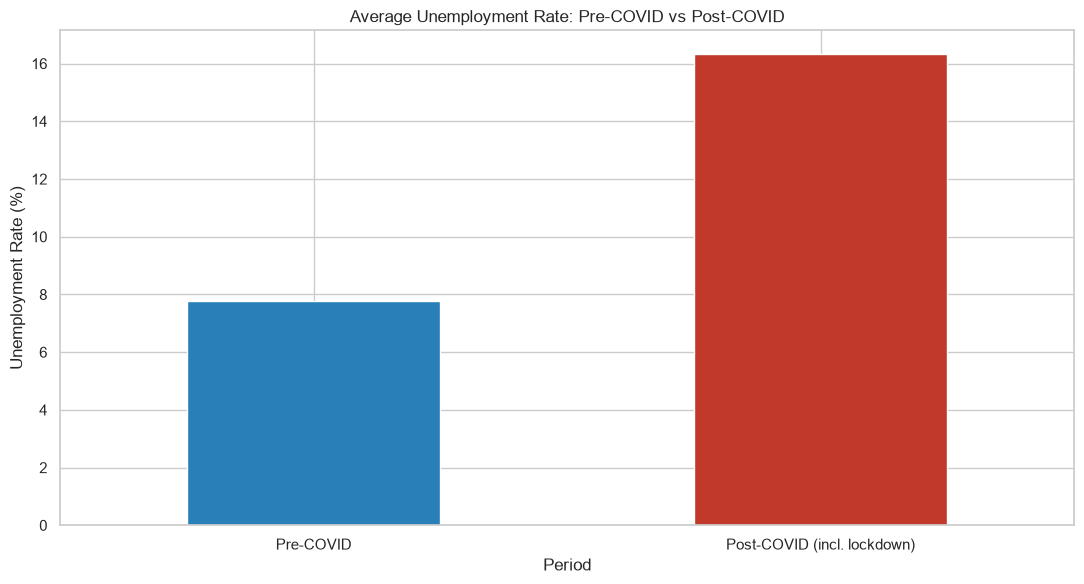


States with biggest unemployment increase:
 Period           Pre-COVID  Post-COVID (incl. lockdown)  Change (pp)
Region                                                              
Tripura              13.38                        27.99        14.61
Haryana              12.92                        26.96        14.04
Jammu & Kashmir      11.48                        23.65        12.17
Chandigarh           10.82                        22.66        11.84
Delhi                10.04                        21.20        11.17
Jharkhand             9.74                        20.49        10.75
Punjab                9.38                        19.83        10.45
Goa                   9.22                        19.37        10.16
Kerala                9.00                        19.06        10.06
Puducherry            8.59                        18.21         9.62


In [2]:
# ==========================================================================
# Unemployment Analysis in India — COVID-19 Impact (single-cell version)
# Place Unemployment_in_India.csv in the same folder, then run this cell.
# ==========================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
pd.set_option("display.max_columns", None)

# ---- 1. Load, inspect, clean, convert types --------------------------------
df = pd.read_csv("Unemployment_in_India.csv")
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

df = df.dropna(how="all")
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y", errors="coerce")
numeric_cols = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)",
]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["Date"] + numeric_cols)
df["Year"], df["Month"] = df["Date"].dt.year, df["Date"].dt.month

# Employment-rate proxy (used in the correlation heatmap)
df["Estimated Employment Rate (%)"] = (
    df["Estimated Labour Participation Rate (%)"]
    * (1 - df["Estimated Unemployment Rate (%)"] / 100)
)
print("\nShape after cleaning:", df.shape)

# ---- 2. EDA: region-wise & month-wise averages ------------------------------
region_avg = (df.groupby("Region")["Estimated Unemployment Rate (%)"]
                .mean().sort_values(ascending=False).round(2))
print("\nRegion-wise average unemployment rate (top 10):\n", region_avg.head(10))

monthwise = (df.groupby(pd.Grouper(key="Date", freq="ME"))
               ["Estimated Unemployment Rate (%)"].mean().round(2))
print("\nMonth-wise all-India average:\n", monthwise)

fig, ax = plt.subplots()
monthwise.plot(ax=ax, marker="o", color="#c0392b")
ax.axvspan(pd.Timestamp("2020-03-25"), pd.Timestamp("2020-06-01"),
           color="grey", alpha=0.2, label="National lockdown (approx.)")
ax.set_title("All-India Average Estimated Unemployment Rate by Month")
ax.set_xlabel("Month"); ax.set_ylabel("Unemployment Rate (%)"); ax.legend()
plt.tight_layout(); plt.show()

# ---- 3. Time series for major states ----------------------------------------
major_states = ["Maharashtra", "Uttar Pradesh", "Tamil Nadu", "Delhi", "Bihar"]
state_ts = (df[df["Region"].isin(major_states)]
            .groupby(["Region", pd.Grouper(key="Date", freq="ME")])
            ["Estimated Unemployment Rate (%)"].mean().reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
for state in major_states:
    subset = state_ts[state_ts["Region"] == state]
    ax.plot(subset["Date"], subset["Estimated Unemployment Rate (%)"], marker="o", label=state)
ax.axvspan(pd.Timestamp("2020-03-25"), pd.Timestamp("2020-06-01"), color="grey", alpha=0.15)
ax.set_title("Unemployment Rate Over Time — Major States")
ax.set_xlabel("Date"); ax.set_ylabel("Unemployment Rate (%)"); ax.legend()
plt.tight_layout(); plt.show()

# ---- 4. Top 10 states bar chart ---------------------------------------------
top10 = region_avg.head(10)
fig, ax = plt.subplots()
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette="Reds_r", legend=False, ax=ax)
ax.set_title("Top 10 States by Average Estimated Unemployment Rate")
ax.set_xlabel("Average Unemployment Rate (%)"); ax.set_ylabel("State")
plt.tight_layout(); plt.show()

# ---- 5. Correlation heatmap ---------------------------------------------
corr_cols = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employment Rate (%)",
    "Estimated Labour Participation Rate (%)",
]
corr_matrix = df[corr_cols].corr().round(2)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation: Unemployment vs Employment vs Labour Participation")
plt.tight_layout(); plt.show()
print("\nCorrelation matrix:\n", corr_matrix)

# ---- 6. Pre-COVID vs post-COVID comparison ----------------------------------
lockdown_start = pd.Timestamp("2020-03-25")
df["Period"] = np.where(df["Date"] < lockdown_start, "Pre-COVID", "Post-COVID (incl. lockdown)")

period_summary = (df.groupby("Period")[corr_cols].mean().round(2)
                     .reindex(["Pre-COVID", "Post-COVID (incl. lockdown)"]))
print("\nPre vs Post-COVID averages:\n", period_summary)

fig, ax = plt.subplots()
period_summary["Estimated Unemployment Rate (%)"].plot(kind="bar", ax=ax, color=["#2980b9", "#c0392b"])
ax.set_title("Average Unemployment Rate: Pre-COVID vs Post-COVID")
ax.set_ylabel("Unemployment Rate (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout(); plt.show()

state_period = (df.groupby(["Region", "Period"])["Estimated Unemployment Rate (%)"]
                  .mean().unstack().reindex(columns=["Pre-COVID", "Post-COVID (incl. lockdown)"]))
state_period["Change (pp)"] = (state_period["Post-COVID (incl. lockdown)"]
                                - state_period["Pre-COVID"]).round(2)
print("\nStates with biggest unemployment increase:\n",
      state_period.sort_values("Change (pp)", ascending=False).round(2).head(10))